# flow2 原三个大阶段研究总结

## Phase 1 三维概率体 → Phase 2 三维属性体 → Phase 4 采集域地球物理

**报告日期：2026-08-01**  
**案例：`cond_generation_0`，稀疏钻井下的 raw label 9 压力测试**

本 Notebook 汇总原计划中三个主要研究方向的设计目的、代码路径、正式运行结果与科学解释。所有数值均从现有权威 JSON/CSV 读取；三维模型、重力场和地震体来自已经保存的严格配对输出。执行本 Notebook **不会训练、不会重新采样、不会覆盖实验目录**。

先给出总判断：

- **Phase 1 成功回答“推理引导能否跨过 soft→hard 边界”**：可以，而且 label 9 的三维 oracle 能显著恢复目标结构。
- **Phase 2a 成功回答“完整多岩性三维属性能否引导全模型”**：在全分辨率、无噪声、高可辨识性属性 oracle 下可以；Phase 2b 与 Phase 3 表明该成功对物性区分度和空间分辨率高度敏感。
- **Phase 4 没有达到最终地质恢复目标**：重力和地震残差都能下降，也能改变数千个 hard 体素，但 label 9 及其主要三维体没有改善。主要瓶颈已经从“梯度是否有效”转变为**物理非唯一性、候选支持不足和物理似然—地质目标错配**。

## 0. 阶段口径与范围

“原三个大阶段”沿用项目此前确定的 Phase 1、Phase 2、Phase 4：

| 层次 | 正式含义 | 在本报告中的位置 |
|---|---|---|
| Phase 0 | checkpoint、EMA、求解器和严格配对审计 | 三阶段共同基础 |
| **Phase 1** | truth-derived label-9 三维概率体引导 | 第一大阶段 |
| **Phase 2** | truth-derived 全岩性三维属性体；含 2a 理想上限与 2b 码表歧义 | 第二大阶段 |
| Phase 3 | 三维属性空间退化/分辨率桥接 | Phase 2→4 的关键过渡证据，不另立为第四方向 |
| **Phase 4** | acquisition-domain 重力、卷积地震及可辨识性诊断 | 第三大阶段 |
| Phase 5 | 原三阶段结束后的无训练反演桥接补充探索 | 仅在附录交代，不混入原三阶段结论 |

Phase 1 和 Phase 2 使用的目标都直接由真值派生，是**信息上限/oracle 实验**；只有 Phase 4 使用采集域正演响应。三者不能都统称为“真实地球物理引导”。

## 1. 总目标与压力测试案例

最终目标不是单向地做一次地球物理反演，而是建立互相约束的生成—地球物理系统：

1. 地球物理观测从全局补足稀疏地表/钻井对深部结构的约束；
2. flow2 学到的地质结构先验以及严格的地表/钻井条件，反过来缩小地球物理非唯一解集合；
3. 输出条件严格满足、观测一致、地质结构合理并保留不确定性的三维模型集合；
4. 成功必须落在 decoded hard label、全模型指标、目标几何和 ensemble 上，连续 loss 下降不能代替地质证据。

`cond_generation_0` 中 label 9 有 **8,968** 个真值体素，钻井仅直接命中 **13** 个（0.145%），9 条钻井中只有 2 条相交。因此它是检验“稀疏局部条件能否由空间广泛信息补足”的合适压力案例。这里的 label 9 只是当前 intrusion-class 演示目标，并不是整个数据集的通用岩脉语义。

## 2. 运行环境、路径定位与权威资产

下面的初始化支持从仓库根目录、项目目录或 Notebook 目录启动。若关键报告缺失会立即报错；可选图片缺失只会给出提示。图表使用现有结果，不运行 GPU。

In [1]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown, Image

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
cjk_font_path = Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")
if cjk_font_path.is_file():
    font_manager.fontManager.addfont(str(cjk_font_path))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(cjk_font_path)).get_name()
else:
    plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.precision", 4)

def locate_project() -> Path:
    starts = [Path.cwd().resolve(), Path.cwd().resolve() / "project" / "geodata-3d-conditional"]
    for start in starts:
        for base in [start, *start.parents]:
            direct = base
            nested = base / "project" / "geodata-3d-conditional"
            for candidate in (direct, nested):
                if (candidate / "docs" / "AGENTS.md").is_file():
                    return candidate.resolve()
    raise FileNotFoundError("无法定位 project/geodata-3d-conditional；请从仓库内启动 Notebook。")

PROJECT = locate_project()
REPO = PROJECT.parents[1]

def load_json(path: Path):
    if not path.is_file():
        raise FileNotFoundError(path)
    return json.loads(path.read_text(encoding="utf-8"))

def load_csv(path: Path):
    if not path.is_file():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def recorded_path(value: str) -> Path:
    path = Path(value)
    if path.is_absolute():
        return path
    return REPO / path

print("PROJECT =", PROJECT)
print("REPO    =", REPO)

PROJECT = /home/xmj/mcy/flowtrain_stochastic_interpolation-main/project/geodata-3d-conditional
REPO    = /home/xmj/mcy/flowtrain_stochastic_interpolation-main


In [2]:
PATHS = {
    "Phase 1 summary": PROJECT / "experiments/stage1_probability/reports/phase1b_v4_12pair/summary.json",
    "Phase 1 pairs": PROJECT / "experiments/stage1_probability/reports/phase1b_v4_12pair/paired_samples.csv",
    "Phase 2a summary": PROJECT / "experiments/stage2_property/reports/phase2a_v1_12pair/summary.json",
    "Phase 2a pairs": PROJECT / "experiments/stage2_property/reports/phase2a_v1_12pair/paired_samples.csv",
    "Phase 2a classes": PROJECT / "experiments/stage2_property/reports/phase2a_v1_12pair/class_summary.csv",
    "Phase 2b screen": PROJECT / "experiments/stage2_property/reports/phase2b_codebook_ambiguity_v1_screen_seed42/level_summary.csv",
    "Phase 2b bracket": PROJECT / "experiments/stage2_property/reports/phase2b_codebook_ambiguity_v1_n4_bracket_seed42/level_summary.csv",
    "Phase 2b c100 fallback": PROJECT / "experiments/stage2_property/reports/phase2b_codebook_ambiguity_v1_n4_fallback_c100_seed42/level_summary.csv",
    "Phase 3 screen": PROJECT / "experiments/stage3_spatial_property/reports/gaussian_screen_seed42_n1/level_summary.csv",
    "Phase 3 identity n4": PROJECT / "experiments/stage3_spatial_property/reports/identity_anchor_v1/seed42_n4_s32_a025_c025/summary.json",
    "Phase 3 sigma1 n4": PROJECT / "experiments/stage3_spatial_property/reports/gaussian_sigma1_v1/seed42_n4_s32_a025_c025/summary.json",
    "Phase 4 gravity a010": PROJECT / "experiments/stage4_gravity/reports/seed42_n1_s32_a010_c025/summary.json",
    "Phase 4 gravity a025": PROJECT / "experiments/stage4_gravity/reports/seed42_n1_s32_a025_c025/summary.json",
    "Phase 4 seismic": PROJECT / "experiments/stage4_seismic/reports/seed42_n1_s32_a025_c025/summary.json",
    "Phase 4d summary": PROJECT / "experiments/stage4_seismic_identifiability/reports/cond_generation_0/fixed12_v1/summary.json",
    "Phase 4d candidates": PROJECT / "experiments/stage4_seismic_identifiability/reports/cond_generation_0/fixed12_v1/candidate_metrics.csv",
}

asset_status = pd.DataFrame(
    [{"资产": name, "存在": path.is_file(), "相对路径": str(path.relative_to(PROJECT))}
     for name, path in PATHS.items()]
)
display(asset_status)
missing = asset_status.loc[~asset_status["存在"], "资产"].tolist()
if missing:
    raise FileNotFoundError(f"缺少权威结果资产: {missing}")

,资产,存在,相对路径
0,Phase 1 summary,True,experiments/stage1_probability/reports/phase1b...
1,Phase 1 pairs,True,experiments/stage1_probability/reports/phase1b...
2,Phase 2a summary,True,experiments/stage2_property/reports/phase2a_v1...
3,Phase 2a pairs,True,experiments/stage2_property/reports/phase2a_v1...
4,Phase 2a classes,True,experiments/stage2_property/reports/phase2a_v1...
5,Phase 2b screen,True,experiments/stage2_property/reports/phase2b_co...
6,Phase 2b bracket,True,experiments/stage2_property/reports/phase2b_co...
7,Phase 2b c100 fallback,True,experiments/stage2_property/reports/phase2b_co...
8,Phase 3 screen,True,experiments/stage3_spatial_property/reports/ga...
9,Phase 3 identity n4,True,experiments/stage3_spatial_property/reports/id...


## 3. 三阶段共同实验协议

所有归因结论建立在同一组不变量上：

- 不修改训练、3D U-Net 或 checkpoint；冻结 `embedding.weight` 使用普通 checkpoint 值，其余 411 个可训练参数使用 EMA。
- baseline 与 guided 使用同一 checkpoint、输入、seed、CPU 初始噪声、时间网格、32 步 fixed-Euler midpoint、温度和非 guidance 参数。
- `alpha=0` 走显式无梯度分支，并必须回归 paired baseline；Dopri5 只保留为历史参考，不能与 fixed-Euler 混作归因对照。
- 采样前及每一步之后重新投影地表、空气和钻井条件；Phase 3/4 中在观测算子前还要用精确硬物性覆盖已知体素，使其观测贡献精确、梯度为零。
- 运行目录不可覆盖；配置、源码、输入、观测和初始噪声均记录哈希。
- 评价同时报告全局 accuracy/mIoU、逐类别 IoU、label-9 IoU/P/R/体积/质心、主体召回、碎片/拓扑、末端 churn、条件违背和 ensemble 多样性。

Phase 0 已经确认：EMA 加载正确、钻井/真值不一致为 0；Dopri5 与 32 步 fixed-Euler 的 hard 结果约有 4.8645% 体素不同，因此后续只能使用严格 fixed-Euler 配对。历史二维 lightweight gravity proxy 在 alpha=0.05 时平均只改变 31.25 个 hard 体素，只证明路径活跃，没有证明 label 9 几何改善。

# 第一大阶段：Phase 1 — label-9 三维概率体上限

## 4. 设计目的与执行路径

Phase 1 先隔离最基础的问题：如果给 frozen flow2 一个与真值对齐的三维 label-9 概率 oracle，推理期梯度能否真正跨过 embedding/decoder 的类别边界并改变 hard 三维结构？

数学路径可概括为：

\[
x_t \xrightarrow{\text{soft decode}} p_t(k,\mathbf r),\qquad
L_{P1}=L_{\mathrm{soft\ BCE}}(p_t(9),P^*)+L_{\mathrm{hard\ Dice}}(p_t(9),M^*)
\]

其中 `P*`/`M*` 直接由真值 label 9 构造。正式确认使用 seeds 42/142/242，每个 seed 4 个样本，共 12 个严格配对；alpha/cap=0.25，`calibrated_soft_bce_hard_dice_v2`、`reference_norm_relative_v2` 和 `windowed_sine`。

主要实现：`guidance/probability_volume.py`、`guidance/probability_sampling.py`、`guidance/probability_evaluation.py`；运行/汇总：`scripts/stage1/run_probability_guidance.py`、`summarize_phase1b.py`。

In [3]:
p1 = load_json(PATHS["Phase 1 summary"])
p1_pairs = load_csv(PATHS["Phase 1 pairs"])

p1_metric_names = {
    "global_voxel_accuracy": "全局 voxel accuracy",
    "global_mean_iou": "全局 dynamic mIoU",
    "target_iou": "label 9 IoU",
    "target_precision": "label 9 Precision",
    "target_recall": "label 9 Recall",
    "target_centroid_distance": "label 9 质心距离（越小越好）",
    "selected_roi_iou": "ROI IoU",
}
rows = []
for key, label in p1_metric_names.items():
    block = p1["metrics"][key]
    b = block["baseline"]["mean"]
    g = block["guided"]["mean"]
    rows.append({"指标": label, "baseline": b, "guided": g, "变化 guided-baseline": g - b})
p1_table = pd.DataFrame(rows)
display(p1_table.style.format({"baseline": "{:.4f}", "guided": "{:.4f}", "变化 guided-baseline": "{:+.4f}"}))
print("严格配对数:", p1["n_pairs"], "；seeds:", p1["seeds"], "；严格配对验证:", p1["strict_pairing_validated"])
print("阶段决定:", p1["gate"]["phase_decision"])
print("严格总门:", p1["gate"]["strict_gate_outcome"],
      "；失败项:", p1["gate"]["failed_entries"],
      "；待审项:", p1["gate"]["pending_entries"])

,指标,baseline,guided,变化 guided-baseline
0,全局 voxel accuracy,0.5972,0.6432,+0.0459
1,全局 dynamic mIoU,0.1804,0.2178,+0.0374
2,label 9 IoU,0.0314,0.8099,+0.7784
3,label 9 Precision,0.0788,0.8274,+0.7486
4,label 9 Recall,0.0520,0.9747,+0.9228
5,label 9 质心距离（越小越好）,16.9518,3.3798,-13.5720
6,ROI IoU,0.0351,0.9392,+0.9041


严格配对数: 12 ；seeds: [42, 142, 242] ；严格配对验证: True
阶段决定: mechanism_validated_with_topology_and_endpoint_caveats
严格总门: not_full_pass ；失败项: ['component_ratio_le_1p25', 'roi_component_ratio_le_1p25_diagnostic', 'no_raw_largest_component_fraction_loss'] ；待审项: ['visible_truth_aligned_structure']


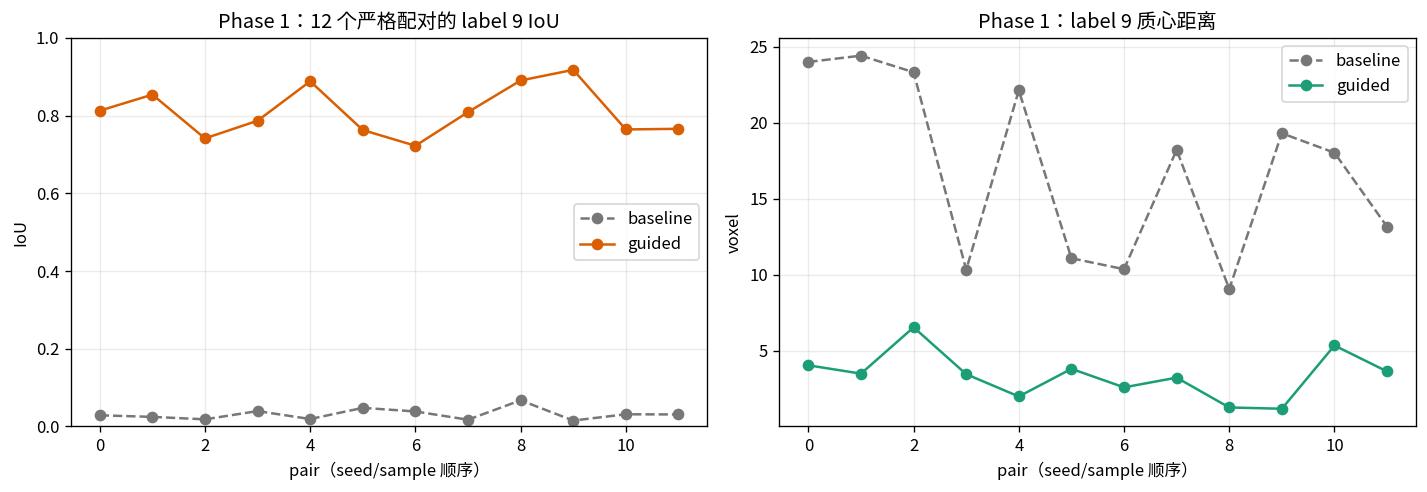

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
pair_x = np.arange(len(p1_pairs))

axes[0].plot(pair_x, p1_pairs["baseline_target_iou"], "o--", label="baseline", color="#777777")
axes[0].plot(pair_x, p1_pairs["guided_target_iou"], "o-", label="guided", color="#d95f02")
axes[0].set_title("Phase 1：12 个严格配对的 label 9 IoU")
axes[0].set_xlabel("pair（seed/sample 顺序）")
axes[0].set_ylabel("IoU")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(pair_x, p1_pairs["baseline_target_centroid_distance"], "o--", label="baseline", color="#777777")
axes[1].plot(pair_x, p1_pairs["guided_target_centroid_distance"], "o-", label="guided", color="#1b9e77")
axes[1].set_title("Phase 1：label 9 质心距离")
axes[1].set_xlabel("pair（seed/sample 顺序）")
axes[1].set_ylabel("voxel")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 4.1 最终 v4 hard 体的直接可视化

仓库中既有 Phase-1 PNG 属于早期 alpha=0.1 screen 或 v3，并不是最终 protocol-v4 12-pair 图，不能冒充最终证据。下面直接读取最终 v4 的 seed42/sample0 严格配对张量，以固定视角显示 label 9；不重新运行采样。

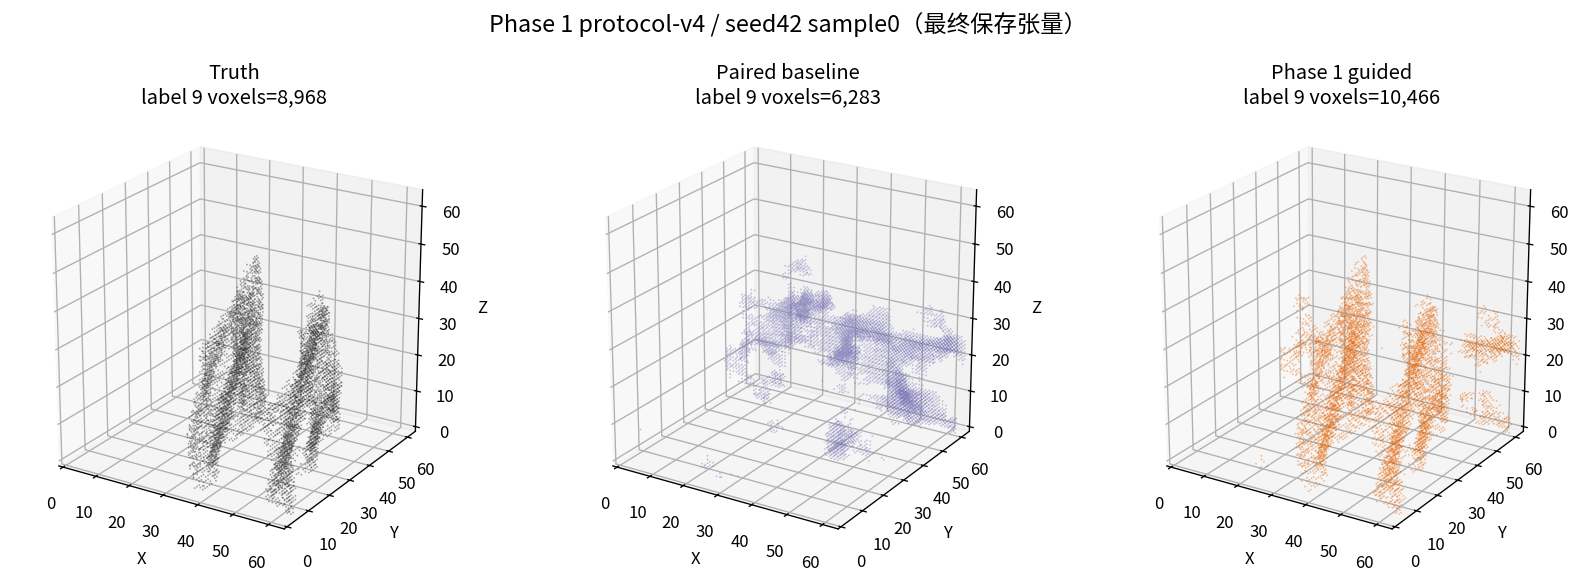

In [5]:
try:
    import torch
except ImportError as exc:
    raise ImportError("需要使用仓库 .venv 内的 PyTorch 读取已保存 .pt；不会调用 GPU。") from exc

def load_volume(path: Path) -> np.ndarray:
    value = torch.load(path, map_location="cpu", weights_only=True)
    if isinstance(value, dict):
        for key in ("samples", "sample", "tensor", "data"):
            if key in value:
                value = value[key]
                break
    array = value.detach().cpu().numpy() if hasattr(value, "detach") else np.asarray(value)
    return np.squeeze(array)

def scatter_label(ax, volume, title, label=9, max_points=6500, color="#e66101"):
    points = np.argwhere(volume == label)
    if len(points) > max_points:
        indices = np.linspace(0, len(points) - 1, max_points, dtype=int)
        points = points[indices]
    if len(points):
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1.2, alpha=0.40, c=color, linewidths=0)
    ax.set_title(f"{title}\nlabel 9 voxels={int(np.sum(volume == label)):,}")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_xlim(0, 63); ax.set_ylim(0, 63); ax.set_zlim(0, 63)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=22, azim=-58)

row = p1_pairs.query("seed == 42 and sample_id == 0").iloc[0]
truth = load_volume(PROJECT / "samples/jupyter-demo/cond_generation_0/true_model.pt")
p1_base_path = recorded_path(row["baseline_path"])
p1_guided_path = p1_base_path.parent.parent / "alpha025" / p1_base_path.name
p1_base_vol = load_volume(p1_base_path)
p1_guided_vol = load_volume(p1_guided_path)

fig = plt.figure(figsize=(14, 4.6))
for idx, (volume, title, color) in enumerate([
    (truth, "Truth", "#252525"),
    (p1_base_vol, "Paired baseline", "#7570b3"),
    (p1_guided_vol, "Phase 1 guided", "#e66101"),
], start=1):
    scatter_label(fig.add_subplot(1, 3, idx, projection="3d"), volume, title, color=color)
fig.suptitle("Phase 1 protocol-v4 / seed42 sample0（最终保存张量）", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 5. Phase 1 结果分析

**已经证明：**

- 12/12 对的 label-9 IoU、Precision、Recall、质心距离和全局指标均改善；label-9 IoU `0.0314→0.8099`，Recall `0.0520→0.9747`，ROI IoU 达 `0.9392`。
- 平均 5.1811% 的全体积 hard label 被改变，其中 98.7588% 位于预定义 ROI；条件违背始终为 0。
- 每个 seed 的 4 个 guided 样本仍然不同，ROI 外 disagreement 保留，所以这不是把所有样本压成一个确定性结果。
- 因此早先担心的“soft guidance 推动了连续状态，但 hard decode 岩性完全不变”在机制层面已经解决：当前路径能够大规模跨越 hard 类别边界。

**没有证明：**

- 目标概率体直接从真值构造，只针对 label 9；它更像把局部硬条件全局化，而不是真正地球物理。
- 原始 component ratio 为 1.2812，高于预注册上限 1.25；largest-component 保守条款与最终固定相机审阅项也未全部通过。因此正式结论是“机制验证成功，带拓扑和末端稳定性局限”，不是无条件 full pass。
- 不能据此删除地表/钻井条件，也不能声称地球物理可以单独唯一恢复三维模型。

# 第二大阶段：Phase 2 — 全岩性三维属性体

## 6. 设计目的与数学路径

Phase 2 把“只告诉模型哪里像 label 9”的概率 oracle，升级为所有类别共同参与的多通道三维属性观测：

\[
p_t(k,\mathbf r)=\operatorname{softmax}_k\frac{\cos(x_t(\mathbf r),e_k)}{\tau_t},\qquad
q_t(j,\mathbf r)=\sum_k p_t(k,\mathbf r)q(j,k)
\]

\[
L_{P2}=\sum_s\lambda_s\left\|W_s\left[S_s(q_t)-S_s(q_{truth})\right]\right\|^2
\]

Phase 2a 使用 truth-derived、全分辨率、无噪声的 density+susceptibility 两通道 distinct codebook，上限性地检验全类别属性路径；Phase 2b 逐步引入属性重叠并降低 label-9 对比度，检验物性可辨识性。数值是受控相对值，不是现场标定物性。

主要实现：`guidance/property_volume.py`、`property_sampling.py`、`property_evaluation.py`；运行/汇总：`scripts/stage2/run_property_guidance.py` 与 `summarize_phase2*.py`。

In [6]:
p2 = load_json(PATHS["Phase 2a summary"])
p2_pairs = load_csv(PATHS["Phase 2a pairs"])
p2_classes = load_csv(PATHS["Phase 2a classes"])

p2_metric_names = {
    "global_voxel_accuracy": "全局 voxel accuracy",
    "truth_present_mean_iou": "truth-present mIoU",
    "global_mean_iou": "dynamic-union mIoU",
    "hard_property_loss": "hard property loss（越小越好）",
    "target_iou": "label 9 IoU",
    "target_precision": "label 9 Precision",
    "target_recall": "label 9 Recall",
    "target_centroid_distance": "label 9 质心距离（越小越好）",
}
rows = []
for key, label in p2_metric_names.items():
    block = p2["metrics"][key]
    b, g = block["baseline"]["mean"], block["guided"]["mean"]
    rows.append({"指标": label, "baseline": b, "guided": g, "变化 guided-baseline": g - b})
p2_table = pd.DataFrame(rows)
display(p2_table.style.format({"baseline": "{:.4f}", "guided": "{:.4f}", "变化 guided-baseline": "{:+.4f}"}))
print("正式决定:", p2["decision"])
print("pair gate:", p2["gates"]["pair_pass_count"], "/", p2["n_pairs"],
      "；seed diversity:", p2["gates"]["seed_diversity_pass_count"], "/", len(p2["seeds"]))

,指标,baseline,guided,变化 guided-baseline
0,全局 voxel accuracy,0.5972,0.6381,+0.0409
1,truth-present mIoU,0.2771,0.3443,+0.0672
2,dynamic-union mIoU,0.1804,0.1980,+0.0176
3,hard property loss（越小越好）,1.4781,0.5187,-0.9594
4,label 9 IoU,0.0314,0.4808,+0.4493
5,label 9 Precision,0.0788,0.9032,+0.8245
6,label 9 Recall,0.0520,0.5075,+0.4555
7,label 9 质心距离（越小越好）,16.9518,3.9825,-12.9694


正式决定: PASS: Phase-2a ideal 3-D property upper bound validated with caveats
pair gate: 12 / 12 ；seed diversity: 3 / 3


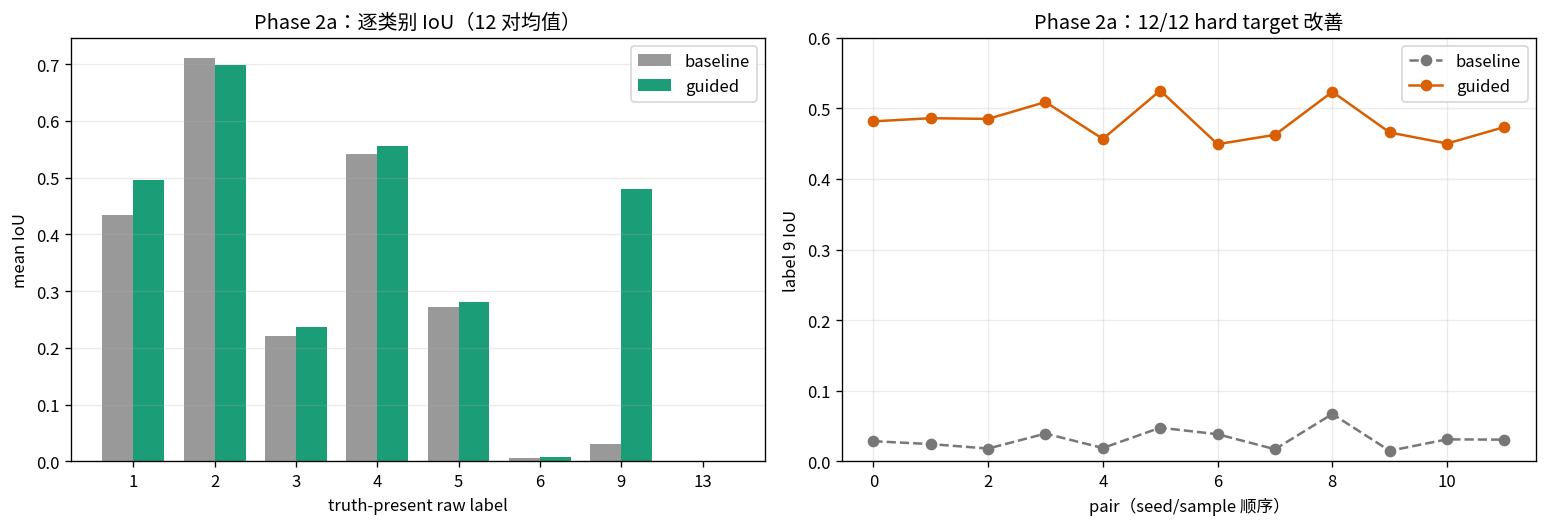

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(p2_classes))
width = 0.38
axes[0].bar(x - width/2, p2_classes["mean_baseline_iou"], width, label="baseline", color="#999999")
axes[0].bar(x + width/2, p2_classes["mean_guided_iou"], width, label="guided", color="#1b9e77")
axes[0].set_xticks(x, p2_classes["class_id"].astype(str))
axes[0].set_xlabel("truth-present raw label")
axes[0].set_ylabel("mean IoU")
axes[0].set_title("Phase 2a：逐类别 IoU（12 对均值）")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

pair_x = np.arange(len(p2_pairs))
axes[1].plot(pair_x, p2_pairs["target_iou"] - p2_pairs["delta_target_iou"], "o--", label="baseline", color="#777777")
axes[1].plot(pair_x, p2_pairs["target_iou"], "o-", label="guided", color="#d95f02")
axes[1].set_ylim(0, 0.6)
axes[1].set_xlabel("pair（seed/sample 顺序）")
axes[1].set_ylabel("label 9 IoU")
axes[1].set_title("Phase 2a：12/12 hard target 改善")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 6.1 Phase 2a 固定相机三维结果

下图来自正式 12-pair 成功集合中的 seed42/sample0（不是按真值挑选的最佳样本），显示 Truth、paired baseline 与 guided label 9。配套 VTK 文件位于同一 figure 目录，可用 PyVista/ParaView 交互查看。

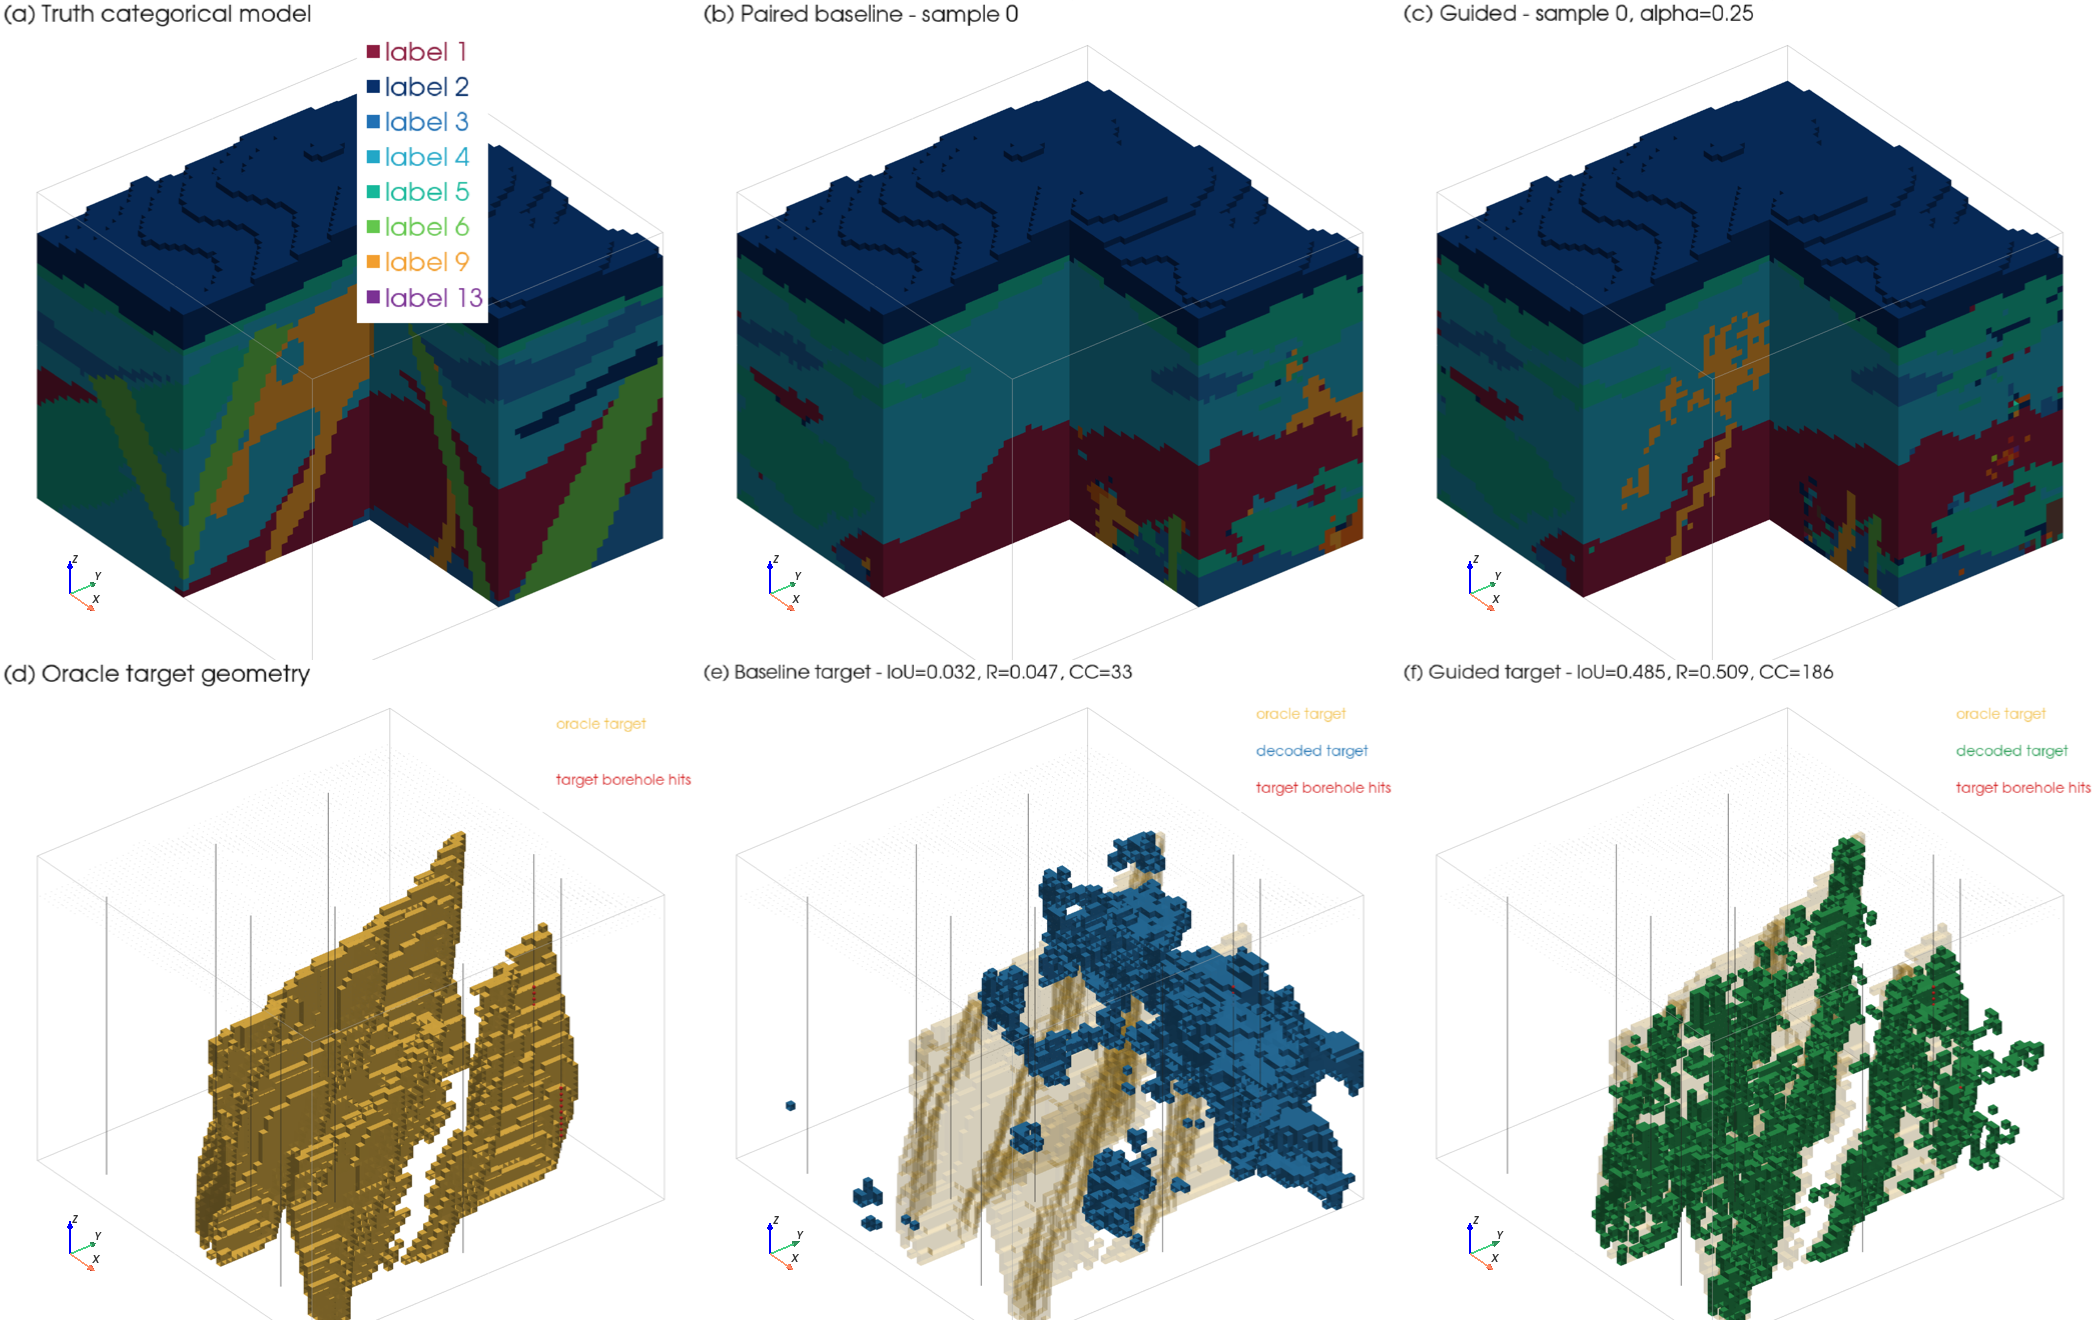

experiments/stage2_property/figures/phase2a_distinct_seed42_n4/truth_baseline_guided_3d.png


In [8]:
p2_figure = PROJECT / "experiments/stage2_property/figures/phase2a_distinct_seed42_n4/truth_baseline_guided_3d.png"
if p2_figure.is_file():
    display(Image(filename=str(p2_figure), width=1100))
    print(p2_figure.relative_to(PROJECT))
else:
    display(Markdown(f"> 可选图片缺失：`{p2_figure}`；指标和正式结论不受影响。"))

## 7. Phase 2b：码表歧义与对比度敏感性

Phase 2a 的 distinct 两通道属性让 label 9 特别可辨识。Phase 2b 保持 sampler、alpha/cap、完整空间分辨率和真值派生目标不变，只改变类别→属性 codebook。最后的 `paired_c004_overlap` 让真值中同时存在的 label 6 与 label 9 在两个通道上完全同码，用来直接测试非唯一性。

,level_id,label9_susceptibility,unique_property_vectors,screen_gate_pass,guided_target_iou,guided_target_precision,guided_target_recall,major_component_min_recall,major_component_mean_recall
0,distinct_c100_anchor,0.1000,15,True,0.4818,0.9004,0.5089,0.3716,0.4925
1,paired_c100,0.1000,9,True,0.4260,0.8699,0.4550,0.2982,0.4383
2,paired_c025,0.0250,9,True,0.3951,0.8632,0.4215,0.2584,0.4025
3,paired_c010,0.0100,9,False,0.2370,0.7569,0.2566,0.0973,0.2362
4,paired_c004_overlap,0.0040,8,False,0.0355,0.1391,0.0455,0.0005,0.0403


,level_id,pair_gate_pass_count,classification,mean_delta_global_voxel_accuracy,mean_delta_truth_present_mean_iou,mean_guided_target_iou,mean_guided_target_precision,mean_guided_target_recall
0,paired_c100,3,transition_region,0.0432,0.0655,0.4412,0.8816,0.4695
1,paired_c025,3,transition_region,0.0411,0.0603,0.4040,0.8762,0.4290
2,paired_c010,0,confirmed_seed42_failure,0.0324,0.0379,0.2376,0.7756,0.2556


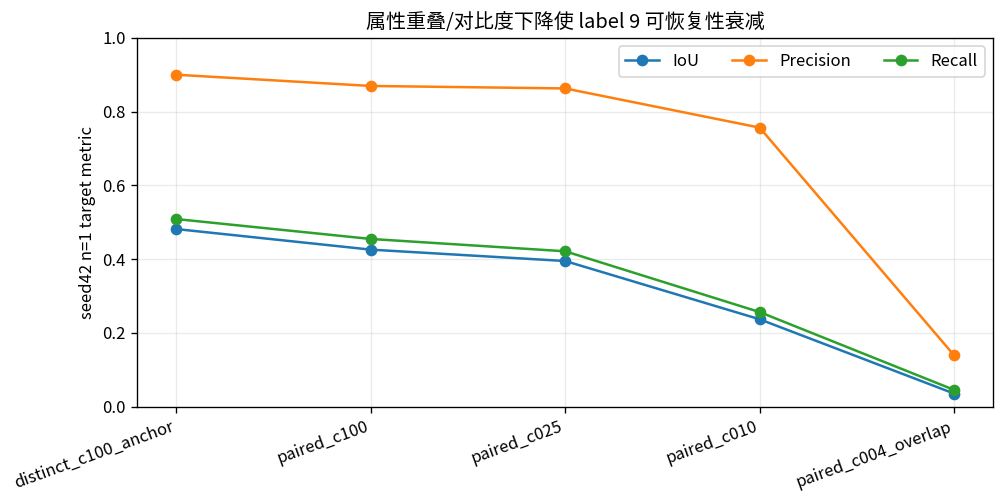

In [9]:
p2b_screen = load_csv(PATHS["Phase 2b screen"])
p2b_bracket = load_csv(PATHS["Phase 2b bracket"])
p2b_c100 = load_csv(PATHS["Phase 2b c100 fallback"])

display(p2b_screen[[
    "level_id", "label9_susceptibility", "unique_property_vectors", "screen_gate_pass",
    "guided_target_iou", "guided_target_precision", "guided_target_recall",
    "major_component_min_recall", "major_component_mean_recall"
]].style.format(precision=4))

p2b_n4 = pd.concat([p2b_c100, p2b_bracket], ignore_index=True).sort_values("order")
display(p2b_n4[[
    "level_id", "pair_gate_pass_count", "classification",
    "mean_delta_global_voxel_accuracy", "mean_delta_truth_present_mean_iou",
    "mean_guided_target_iou", "mean_guided_target_precision", "mean_guided_target_recall"
]].style.format(precision=4))

fig, ax = plt.subplots(figsize=(8.5, 4.3))
x = np.arange(len(p2b_screen))
ax.plot(x, p2b_screen["guided_target_iou"], "o-", label="IoU")
ax.plot(x, p2b_screen["guided_target_precision"], "o-", label="Precision")
ax.plot(x, p2b_screen["guided_target_recall"], "o-", label="Recall")
ax.set_xticks(x, p2b_screen["level_id"], rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("seed42 n=1 target metric")
ax.set_title("属性重叠/对比度下降使 label 9 可恢复性衰减")
ax.legend(ncol=3)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Phase 2 结论

**Phase 2a 达到其“理想属性上限”设计目的：**

- 12/12 严格配对全部通过：accuracy `0.5972→0.6381`，truth-present mIoU `0.2771→0.3443`，hard-property loss `1.4781→0.5187`；label-9 IoU/P/R 到 `0.4808/0.9032/0.5075`。
- 至少 5/8 个真值非空气类别在每对中改善；条件为 0 违背且 ensemble diversity 保留。
- 说明全类别 soft probability→多通道期望属性→hard geology 的路径能够工作，并不只是 label 9 二元赋值。

**但 Phase 2 也暴露了关键限制：**

- label 2 在 12/12 对中下降，label 13 完全未恢复；label 9 定位较准但体积不足、结构仍碎片化。
- `paired_c100` 和 `paired_c025` 的 n=4 均只有 3/4，是 transition 而不是可晋级 pass；`paired_c010` 为 0/4；label 6/9 完全同码时单样本几乎失去 label-9 恢复能力。
- “label 6/9 完全同码”不是软件错误，而是两类的观测属性向量相同。损失无法从属性上区分二者，只能依赖 prior/空间上下文；当前 prior 和稀疏条件不足以稳定做出正确选择。
- Phase 2 的属性体仍是 truth-derived、全分辨率、无噪声 inversion surrogate，不是从真实重力/地震反演得到的三维物性体。

# 过渡证据：Phase 3 — 三维属性的空间退化

Phase 3 不另立为原计划第四个方向。它只问一个桥接问题：Phase 2a 的成功如果经历类似反演分辨率损失的空间模糊，还剩多少？实验从唯一 12/12 通过的 distinct codebook 出发，只把观测算子改为 identity 或三维 Gaussian σ=1/2/4 voxel；所有控制器和严格配对条件保持不变。

,level,passed,delta_hard_observation_loss,target_iou,target_precision,target_recall,major_component_mean_recall,delta_global_voxel_accuracy,delta_truth_present_mean_iou
0,identity_anchor_v1,True,-1.0173,0.4881,0.9032,0.5151,0.4984,0.0413,0.0676
1,gaussian_sigma1_v1,False,-1.0867,0.3357,0.6758,0.4001,0.3981,0.0312,0.0458
2,gaussian_sigma2_v1,False,-1.0466,0.2064,0.4935,0.2619,0.2584,0.0217,0.0272
3,gaussian_sigma4_v1,False,-0.9980,0.1026,0.2997,0.1349,0.1305,0.0128,0.0117


,level,n,pair gate pass,classification
0,identity,4,4,confirmed_seed42_pass
1,Gaussian σ=1,4,0,confirmed_seed42_failure


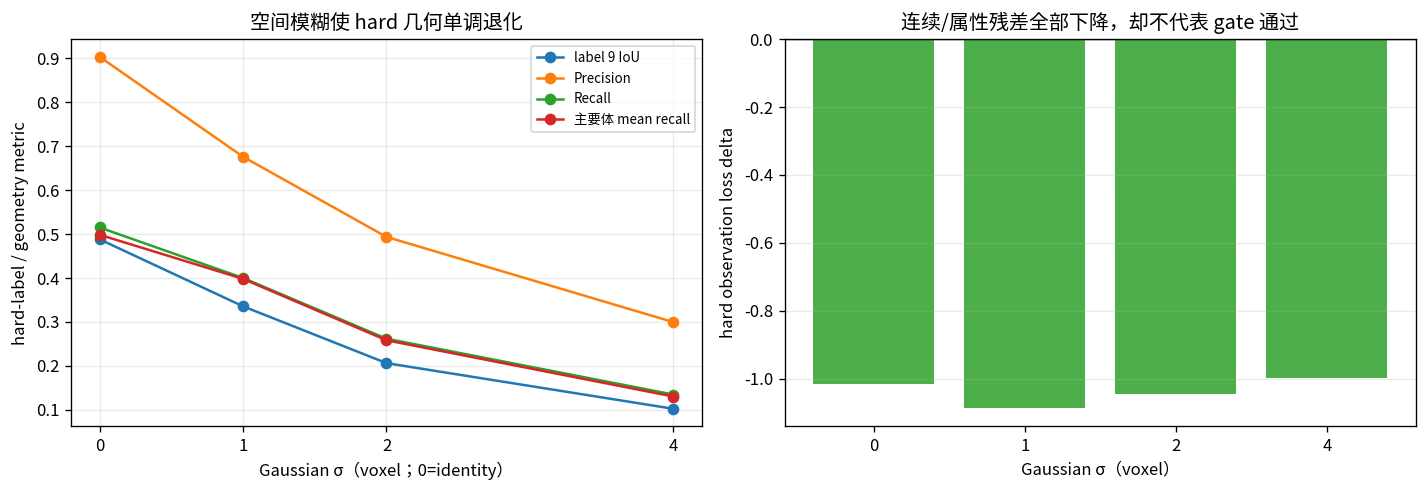

In [10]:
p3 = load_csv(PATHS["Phase 3 screen"])
p3_identity_n4 = load_json(PATHS["Phase 3 identity n4"])
p3_sigma1_n4 = load_json(PATHS["Phase 3 sigma1 n4"])
sigma_map = {"identity_anchor_v1": 0, "gaussian_sigma1_v1": 1, "gaussian_sigma2_v1": 2, "gaussian_sigma4_v1": 4}
p3["sigma_voxel"] = p3["level"].map(sigma_map)

display(p3[[
    "level", "passed", "delta_hard_observation_loss", "target_iou", "target_precision",
    "target_recall", "major_component_mean_recall", "delta_global_voxel_accuracy",
    "delta_truth_present_mean_iou"
]].style.format(precision=4))

confirm = pd.DataFrame([
    {"level": "identity", "n": 4, "pair gate pass": p3_identity_n4["pair_gate_pass_count"], "classification": p3_identity_n4["classification"]},
    {"level": "Gaussian σ=1", "n": 4, "pair gate pass": p3_sigma1_n4["pair_gate_pass_count"], "classification": p3_sigma1_n4["classification"]},
])
display(confirm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for key, label in [("target_iou", "label 9 IoU"), ("target_precision", "Precision"), ("target_recall", "Recall"),
                   ("major_component_mean_recall", "主要体 mean recall")]:
    axes[0].plot(p3["sigma_voxel"], p3[key], "o-", label=label)
axes[0].set_xticks([0, 1, 2, 4])
axes[0].set_xlabel("Gaussian σ（voxel；0=identity）")
axes[0].set_ylabel("hard-label / geometry metric")
axes[0].set_title("空间模糊使 hard 几何单调退化")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].bar(p3["sigma_voxel"].astype(str), p3["delta_hard_observation_loss"], color="#4daf4a")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Gaussian σ（voxel）")
axes[1].set_ylabel("hard observation loss delta")
axes[1].set_title("连续/属性残差全部下降，却不代表 gate 通过")
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Phase 3 的 identity 在 n=4 中 4/4 通过，说明新观测接口能复现 Phase 2a；但 σ=1 已在 n=4 中 0/4 失败，σ=2/4 的单样本也更差。所有层级的观测 loss 都下降，却没有一个非零 Gaussian 层级通过完整 hard 地质门。

这意味着 Phase 2a 的正结果高度依赖**全分辨率、高可辨识性、无噪声三维属性**。把 Phase 2 直接称为“真实反演属性体可用”是不成立的；它与采集域 Phase 4 之间存在明显的信息断崖。原计划中的 Phase-4b smooth-3D+gravity 联合臂因此没有合法的非零模糊工作点，未被执行。

# 第三大阶段：Phase 4 — 采集域地球物理引导

## 9. 设计目的与三条证据链

Phase 4 首次用采集域可微正演响应替代 truth-derived 三维属性 oracle：

- **Phase 4a 重力：**完整类别密度映射、矩形棱柱垂向重力、全体素—全测站支撑、SI→mGal、64×64 无噪声 surface survey。
- **Phase 4c 卷积地震：**完整 density/velocity/impedance/slowness codebook，逐柱双程时映射，320 点×8 ms，25 Hz Ricker 子波，完整 64×64 lateral cube。
- **Phase 4d 可辨识性/后验选择：**不做梯度更新，只对冻结的 12 个 flow baseline 候选按 hard seismic loss 排序，判断是优化器问题、候选池问题还是似然错配。

两个正演实验都故意采用 truth-derived、无噪声、inverse-crime、高对比度的有利上限；仍然不是实测数据。条件体素在每次正演前被精确覆盖，梯度为零。

,实验,样本数,正式分类,物理 RMSE baseline,物理 RMSE guided,物理 RMSE 变化,accuracy 变化,label9 IoU baseline,label9 IoU guided,label9 Recall baseline,label9 Recall guided,主要体 mean recall
0,Phase 4a gravity α=0.10,1,single_sample_failure,0.95848,0.87032,-0.08815,0.00610,0.02860,0.02111,0.04728,0.03033,0.02797
1,Phase 4a gravity α=0.25,1,single_sample_failure,0.95848,0.89287,-0.06561,0.00907,0.02860,0.01590,0.04728,0.02074,0.02050
2,Phase 4c seismic α=0.25,1,single_sample_failure,0.04226,0.03905,-0.00321,0.00235,0.02860,0.02593,0.04728,0.03947,0.03568


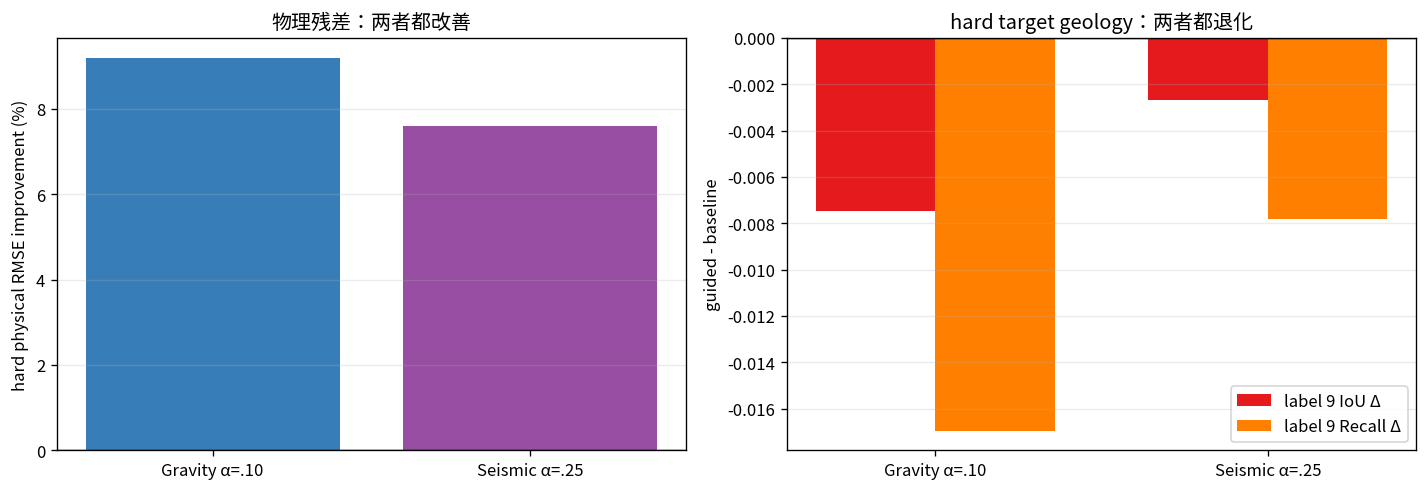

In [11]:
g010 = load_json(PATHS["Phase 4 gravity a010"])
g025 = load_json(PATHS["Phase 4 gravity a025"])
seis = load_json(PATHS["Phase 4 seismic"])

def phase4_row(name, summary, rmse_key):
    base = summary["aggregate"]["baseline_mean"]
    guided = summary["aggregate"]["guided_mean"]
    return {
        "实验": name,
        "样本数": summary["n_samples"],
        "正式分类": summary["classification"],
        "物理 RMSE baseline": base[rmse_key],
        "物理 RMSE guided": guided[rmse_key],
        "物理 RMSE 变化": guided[rmse_key] - base[rmse_key],
        "accuracy 变化": guided["global_voxel_accuracy"] - base["global_voxel_accuracy"],
        "label9 IoU baseline": base["target_iou"],
        "label9 IoU guided": guided["target_iou"],
        "label9 Recall baseline": base["target_recall"],
        "label9 Recall guided": guided["target_recall"],
        "主要体 mean recall": summary["aggregate"]["gate_mean"]["major_component_mean_recall"],
    }

p4_table = pd.DataFrame([
    phase4_row("Phase 4a gravity α=0.10", g010, "hard_gravity_rmse_mgal"),
    phase4_row("Phase 4a gravity α=0.25", g025, "hard_gravity_rmse_mgal"),
    phase4_row("Phase 4c seismic α=0.25", seis, "hard_seismic_rmse_amplitude"),
])
display(p4_table.style.format(precision=5))

main_rows = p4_table.iloc[[0, 2]].copy()
rmse_improve_pct = 100 * (main_rows["物理 RMSE baseline"] - main_rows["物理 RMSE guided"]) / main_rows["物理 RMSE baseline"]
iou_delta = main_rows["label9 IoU guided"] - main_rows["label9 IoU baseline"]
recall_delta = main_rows["label9 Recall guided"] - main_rows["label9 Recall baseline"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
labels = ["Gravity α=.10", "Seismic α=.25"]
axes[0].bar(labels, rmse_improve_pct, color=["#377eb8", "#984ea3"])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("hard physical RMSE improvement (%)")
axes[0].set_title("物理残差：两者都改善")
axes[0].grid(axis="y", alpha=0.25)

x = np.arange(2); width = 0.36
axes[1].bar(x - width/2, iou_delta, width, label="label 9 IoU Δ", color="#e41a1c")
axes[1].bar(x + width/2, recall_delta, width, label="label 9 Recall Δ", color="#ff7f00")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x, labels)
axes[1].set_ylabel("guided - baseline")
axes[1].set_title("hard target geology：两者都退化")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Phase 4a 重力：已保存场的观测—预测—残差

正式 alpha=0.10 诊断把 hard gravity RMSE 从 0.95848 降到 0.87032 mGal，但 label-9 IoU/Recall 从 0.02860/0.04728 降到 0.02111/0.03033。下面直接读取该严格配对保存的 2D 场。

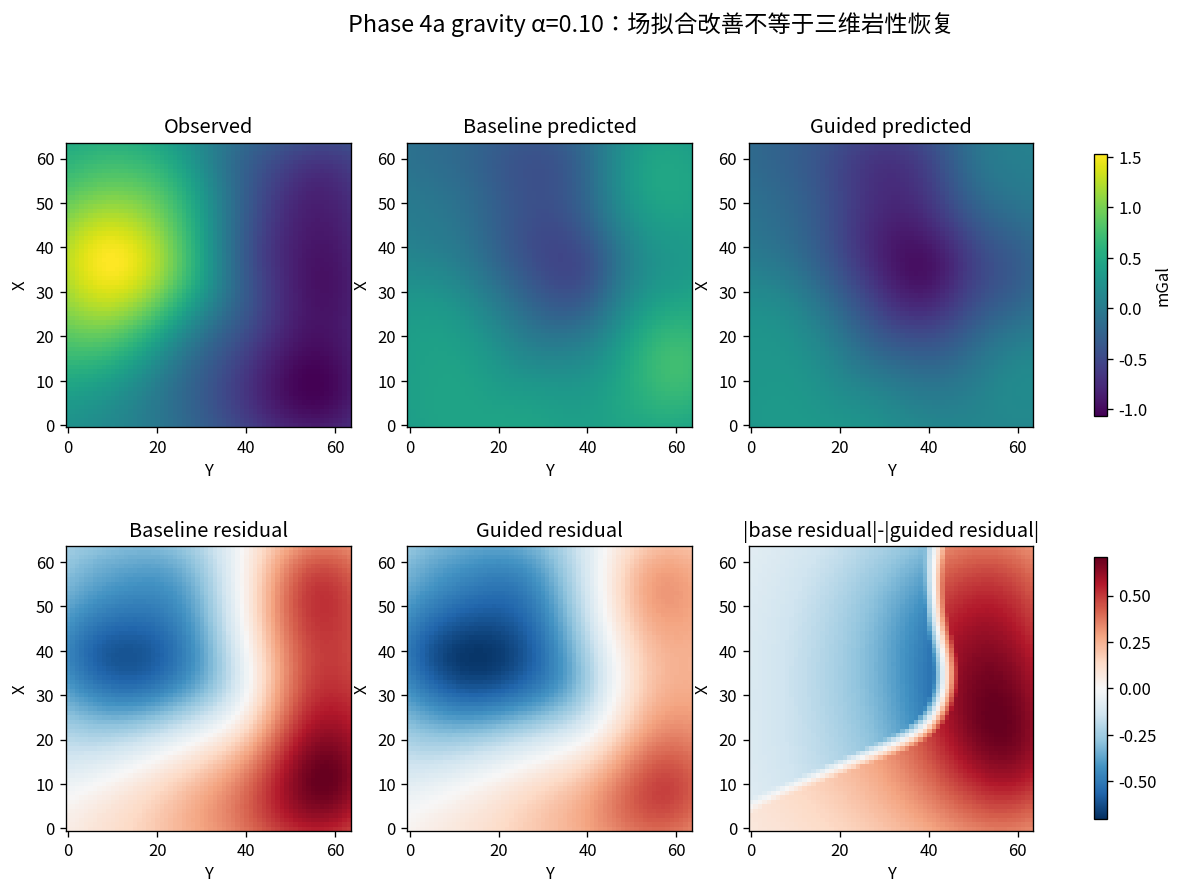

In [12]:
gravity_run = PROJECT / "experiments/stage4_gravity/runs/cond_generation_0/phase4a_gravity_v1/seed42_n1_s32_a010_c025"
g_obs = load_volume(gravity_run / "baseline/observed_gravity_mgal.pt")
g_base = load_volume(gravity_run / "baseline/hard_gravity_fields_mgal.pt")
g_guided = load_volume(gravity_run / "alpha010/hard_gravity_fields_mgal.pt")
g_res_base = g_base - g_obs
g_res_guided = g_guided - g_obs

field_min = min(g_obs.min(), g_base.min(), g_guided.min())
field_max = max(g_obs.max(), g_base.max(), g_guided.max())
residual_limit = max(np.abs(g_res_base).max(), np.abs(g_res_guided).max())
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, data, title in zip(axes[0], [g_obs, g_base, g_guided], ["Observed", "Baseline predicted", "Guided predicted"]):
    im = ax.imshow(data, origin="lower", cmap="viridis", vmin=field_min, vmax=field_max)
    ax.set_title(title); ax.set_xlabel("Y"); ax.set_ylabel("X")
fig.colorbar(im, ax=axes[0].ravel().tolist(), shrink=0.78, label="mGal")
for ax, data, title in zip(axes[1], [g_res_base, g_res_guided, np.abs(g_res_base)-np.abs(g_res_guided)],
                           ["Baseline residual", "Guided residual", "|base residual|-|guided residual|"]):
    lim = residual_limit if "|base" not in title else max(np.abs(data).max(), 1e-12)
    im2 = ax.imshow(data, origin="lower", cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_title(title); ax.set_xlabel("Y"); ax.set_ylabel("X")
fig.colorbar(im2, ax=axes[1].ravel().tolist(), shrink=0.78)
fig.suptitle("Phase 4a gravity α=0.10：场拟合改善不等于三维岩性恢复", y=0.99, fontsize=14)
plt.show()

## 11. Phase 4c 地震：已保存体的剖面与残差

地震 cube 保留横向与时间定位，但它主要约束声学界面和到时，而不是每个体素的唯一岩性。正式结果的 hard seismic RMSE 从 0.042262 降到 0.039048；label-9 IoU/Recall 却下降到 0.02593/0.03947。

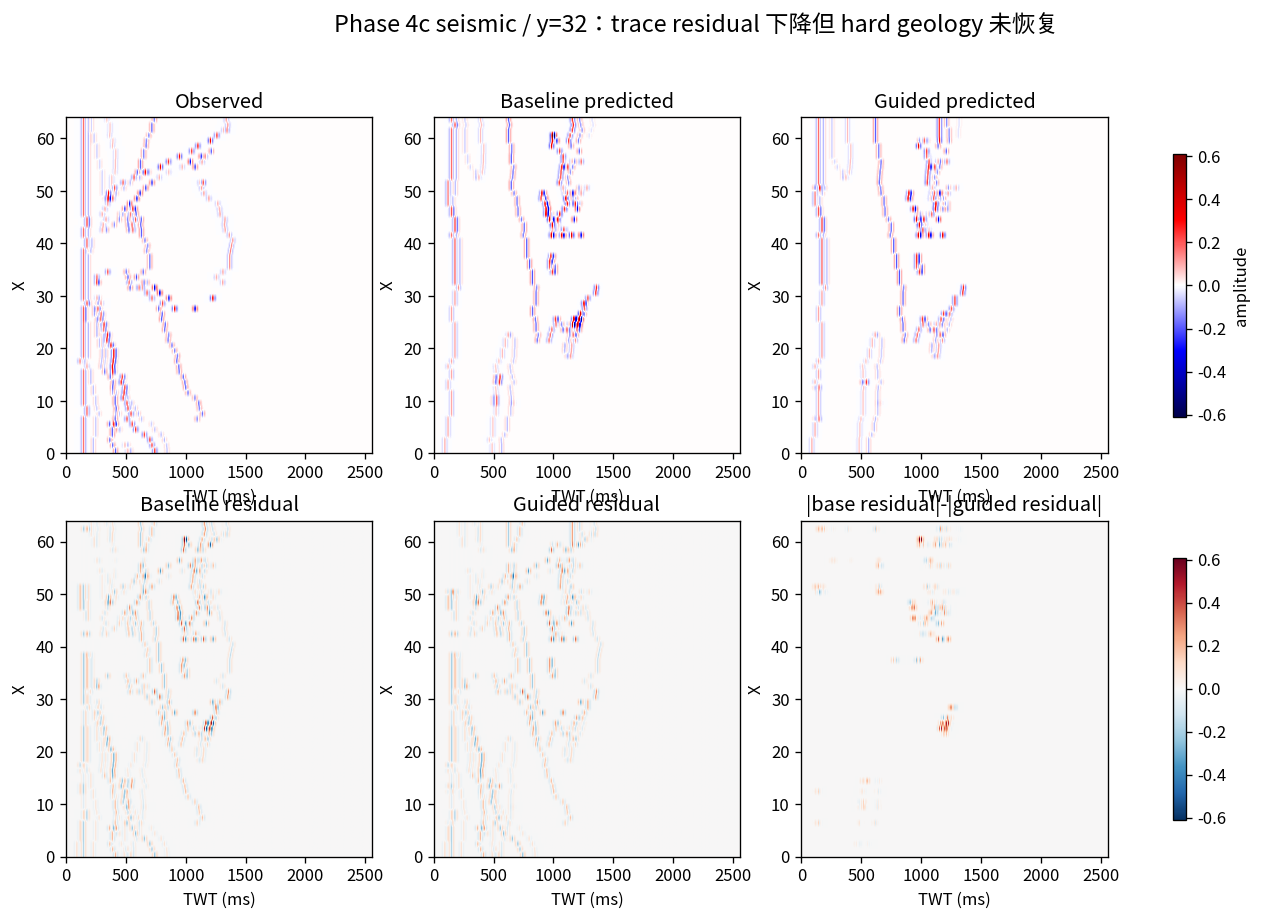

In [13]:
seismic_run = PROJECT / "experiments/stage4_seismic/runs/cond_generation_0/phase4c_seismic_v1/seed42_n1_s32_a025_c025"
s_obs = load_volume(seismic_run / "baseline/observed_seismic.pt")
s_base = load_volume(seismic_run / "baseline/hard_seismic_fields.pt")
s_guided = load_volume(seismic_run / "alpha025/hard_seismic_fields.pt")
y_index = s_obs.shape[1] // 2
sections = [s_obs[:, y_index, :], s_base[:, y_index, :], s_guided[:, y_index, :]]
residuals = [s_base[:, y_index, :] - s_obs[:, y_index, :], s_guided[:, y_index, :] - s_obs[:, y_index, :]]
amp_limit = max(np.abs(item).max() for item in sections)
res_limit = max(np.abs(item).max() for item in residuals)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
extent = [0, sections[0].shape[1] * 8, 0, sections[0].shape[0]]
for ax, data, title in zip(axes[0], sections, ["Observed", "Baseline predicted", "Guided predicted"]):
    im = ax.imshow(data, aspect="auto", origin="lower", cmap="seismic", vmin=-amp_limit, vmax=amp_limit, extent=extent)
    ax.set_title(title); ax.set_xlabel("TWT (ms)"); ax.set_ylabel("X")
fig.colorbar(im, ax=axes[0].ravel().tolist(), shrink=0.78, label="amplitude")
bottom_data = [residuals[0], residuals[1], np.abs(residuals[0])-np.abs(residuals[1])]
bottom_titles = ["Baseline residual", "Guided residual", "|base residual|-|guided residual|"]
for ax, data, title in zip(axes[1], bottom_data, bottom_titles):
    lim = max(np.abs(data).max(), 1e-12) if "|base" in title else res_limit
    im2 = ax.imshow(data, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-lim, vmax=lim, extent=extent)
    ax.set_title(title); ax.set_xlabel("TWT (ms)"); ax.set_ylabel("X")
fig.colorbar(im2, ax=axes[1].ravel().tolist(), shrink=0.78)
fig.suptitle(f"Phase 4c seismic / y={y_index}：trace residual 下降但 hard geology 未恢复", y=0.99, fontsize=14)
plt.show()

### 11.1 Phase 4 hard label 的变化方向

重力和地震都已经改变数千个 hard 体素，因此 Phase 4 失败不能再归因于“soft-hard 映射完全没解决”。下面用 label-9 最大投影显示：物理引导确实改了模型，但主要是在删除/重排 label 9，而不是恢复真值中缺失的四个主体。

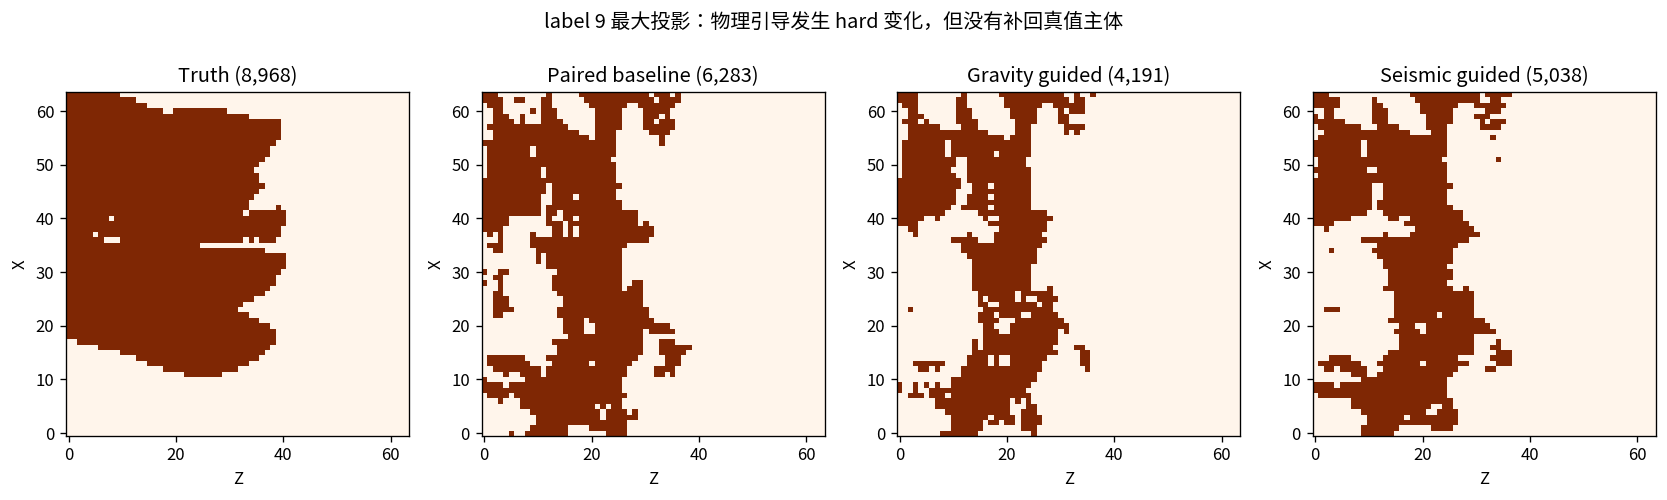

In [14]:
g_base_vol = load_volume(gravity_run / "baseline/sample_0.pt")
g_guided_vol = load_volume(gravity_run / "alpha010/sample_0.pt")
s_guided_vol = load_volume(seismic_run / "alpha025/sample_0.pt")

def label_mip(volume, label=9, axis=1):
    return np.max(volume == label, axis=axis).astype(float)

volumes = [truth, g_base_vol, g_guided_vol, s_guided_vol]
titles = [
    f"Truth ({np.sum(truth == 9):,})",
    f"Paired baseline ({np.sum(g_base_vol == 9):,})",
    f"Gravity guided ({np.sum(g_guided_vol == 9):,})",
    f"Seismic guided ({np.sum(s_guided_vol == 9):,})",
]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, volume, title in zip(axes, volumes, titles):
    ax.imshow(label_mip(volume), origin="lower", cmap="Oranges", vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel("Z"); ax.set_ylabel("X")
fig.suptitle("label 9 最大投影：物理引导发生 hard 变化，但没有补回真值主体", y=1.03)
plt.tight_layout()
plt.show()

## 12. Phase 4d：固定候选池可辨识性与后验选择

若直接梯度引导失败，仍可能是优化器没有找到好样本。Phase 4d 因此冻结 Phase 2a 的 12 个 alpha-zero baseline，完全不改变地质体，只按 hard seismic loss 排序；真值只在排序之后用于审计。

,统计,label9 IoU,label9 Recall,主要体 mean recall
0,12候选均值,0.0314,0.0520,0.0534
1,seismic top-3均值,0.0236,0.0370,0.0391
2,oracle best（非可部署）,0.0672,0.0959,0.0963


support gate passing candidates: []
selected candidate: seed42_sample1
decision: FAIL: frozen prior pool lacks geological support


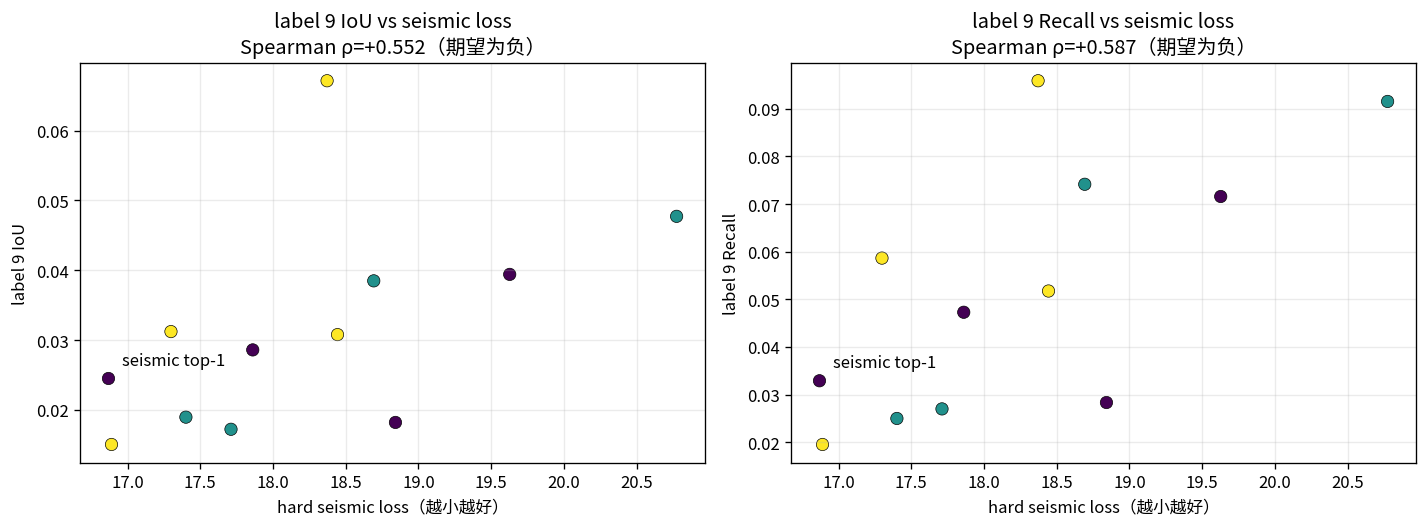

In [15]:
p4d = load_json(PATHS["Phase 4d summary"])
candidates = load_csv(PATHS["Phase 4d candidates"])
selection = p4d["selection"]
corr = selection["correlations"]

p4d_table = pd.DataFrame([
    {"统计": "12候选均值", "label9 IoU": selection["ensemble_mean"]["target_iou"],
     "label9 Recall": selection["ensemble_mean"]["target_recall"],
     "主要体 mean recall": selection["ensemble_mean"]["major_component_mean_recall"]},
    {"统计": "seismic top-3均值", "label9 IoU": selection["top_three_mean"]["target_iou"],
     "label9 Recall": selection["top_three_mean"]["target_recall"],
     "主要体 mean recall": selection["top_three_mean"]["major_component_mean_recall"]},
    {"统计": "oracle best（非可部署）", "label9 IoU": selection["oracle_best"]["target_iou"]["value"],
     "label9 Recall": selection["oracle_best"]["target_recall"]["value"],
     "主要体 mean recall": selection["oracle_best"]["major_component_mean_recall"]["value"]},
])
display(p4d_table.style.format(precision=4))
print("support gate passing candidates:", selection["support_gate"]["passing_candidate_ids"])
print("selected candidate:", selection["selected_candidate_id"])
print("decision:", selection["decision"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, key, label in [
    (axes[0], "target_iou", "label 9 IoU"),
    (axes[1], "target_recall", "label 9 Recall"),
]:
    ax.scatter(candidates["hard_seismic_loss"], candidates[key], c=candidates["seed"], cmap="viridis", s=55, edgecolor="black", linewidth=0.4)
    top = candidates.loc[candidates["hard_seismic_loss"].idxmin()]
    ax.annotate("seismic top-1", (top["hard_seismic_loss"], top[key]), xytext=(8, 8), textcoords="offset points")
    rho = corr[key]["spearman_rho"]
    ax.set_title(f"{label} vs seismic loss\nSpearman ρ={rho:+.3f}（期望为负）")
    ax.set_xlabel("hard seismic loss（越小越好）")
    ax.set_ylabel(label)
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 13. Phase 4 结果分析

**正演与推理链在技术上有效：**

- 重力、地震都通过 EMA、哈希、固定噪声、alpha-zero 回归、条件投影和数值梯度审计；物理 residual 确实下降。
- 重力 alpha=.25/.10 分别改变 6,562/3,756 个 hard 体素；地震改变 3,737 个。soft→hard 边界已经跨越，条件违背仍为 0。

**但第三大阶段没有达到最终预期：**

- 重力通过在深度和岩性之间重新分配密度、删除错位 label-9 质量来降低二维积分场残差；alpha=.10 中 2,101 个体素离开 label 9，只有 9 个进入。
- 地震保留到时和界面定位，却仍允许阻抗相近/界面等效的岩性交换；1,438 个体素离开 label 9，只有 193 个进入。
- Phase 4d 的 12 个候选中没有一个达到 label-9/主体支持门；甚至 oracle best IoU/Recall 也只有 0.0672/0.0959。低 seismic loss 对 label-9 IoU/Recall 的 Spearman 方向为正 `+0.552/+0.587`，与“loss 越低、地质越好”的期望负方向相反。

因而失败包含两个层次：

1. **proposal support 不足：** frozen sparse-conditioned flow baseline 很少生成真值附近的 label-9 主体，后验重排不能选择一个根本不存在的候选；
2. **likelihood/geology misalignment：** 全局物理 loss 可以被其他类别、界面、深度和时深误差补偿，低 residual 不等于目标岩性正确。

这是一组有效负结果，不是运行失败；也不证明所有地震、弹性、多属性、局部结构似然或地球物理感知训练都必然失败。

# 14. 三阶段横向总结

下表把证据按“信息特权逐步降低”的顺序排列。各行样本数和实验问题不同，不能把绝对值当成同一统计总体作直接显著性比较；它用于展示结论方向和信息断崖。

,证据层级,n pairs,输入信息,baseline IoU,guided IoU,结论
0,Phase 1 label-9 probability oracle,12,truth-derived 单标签3D,0.0314,0.8099,机制成功；非真实地球物理
1,Phase 2a distinct property oracle,12,truth-derived 全岩性双通道3D,0.0314,0.4808,理想属性上限成功
2,Phase 3 Gaussian σ=1,4,空间模糊3D属性,0.0277,0.3482,0/4；无非零模糊工作点
3,Phase 4a gravity α=.10,1,2D surface gravity,0.0286,0.0211,物理残差降、hard target退化
4,Phase 4c seismic α=.25,1,3D lateral-time seismic cube,0.0286,0.0259,物理残差降、hard target退化


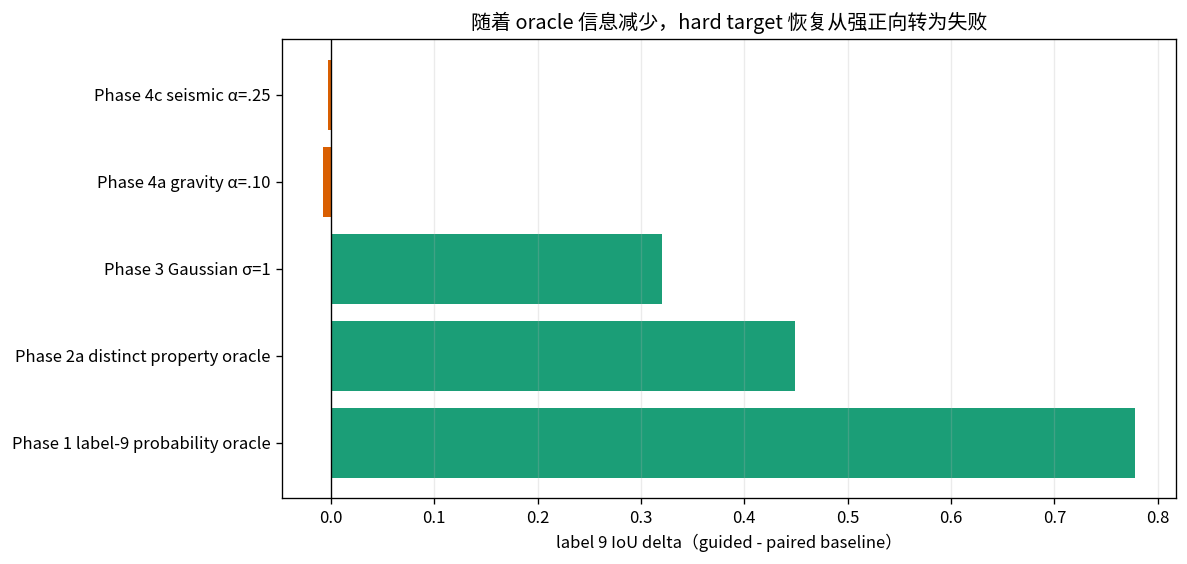

In [16]:
def p1_pair(key):
    block = p1["metrics"][key]
    return block["baseline"]["mean"], block["guided"]["mean"]

def p2_pair(key):
    block = p2["metrics"][key]
    return block["baseline"]["mean"], block["guided"]["mean"]

p3_sigma1 = p3.loc[p3["sigma_voxel"] == 1].iloc[0]
evidence = pd.DataFrame([
    {"证据层级": "Phase 1 label-9 probability oracle", "n pairs": 12, "输入信息": "truth-derived 单标签3D", "baseline IoU": p1_pair("target_iou")[0], "guided IoU": p1_pair("target_iou")[1], "结论": "机制成功；非真实地球物理"},
    {"证据层级": "Phase 2a distinct property oracle", "n pairs": 12, "输入信息": "truth-derived 全岩性双通道3D", "baseline IoU": p2_pair("target_iou")[0], "guided IoU": p2_pair("target_iou")[1], "结论": "理想属性上限成功"},
    {"证据层级": "Phase 3 Gaussian σ=1", "n pairs": 4, "输入信息": "空间模糊3D属性", "baseline IoU": p3_sigma1_n4["aggregate"]["baseline_mean"]["target_iou"], "guided IoU": p3_sigma1_n4["aggregate"]["guided_mean"]["target_iou"], "结论": "0/4；无非零模糊工作点"},
    {"证据层级": "Phase 4a gravity α=.10", "n pairs": 1, "输入信息": "2D surface gravity", "baseline IoU": g010["aggregate"]["baseline_mean"]["target_iou"], "guided IoU": g010["aggregate"]["guided_mean"]["target_iou"], "结论": "物理残差降、hard target退化"},
    {"证据层级": "Phase 4c seismic α=.25", "n pairs": 1, "输入信息": "3D lateral-time seismic cube", "baseline IoU": seis["aggregate"]["baseline_mean"]["target_iou"], "guided IoU": seis["aggregate"]["guided_mean"]["target_iou"], "结论": "物理残差降、hard target退化"},
])
display(evidence.style.format({"baseline IoU": "{:.4f}", "guided IoU": "{:.4f}"}))

evidence["IoU delta"] = evidence["guided IoU"] - evidence["baseline IoU"]
colors = ["#1b9e77" if value > 0 else "#d95f02" for value in evidence["IoU delta"]]
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(evidence["证据层级"], evidence["IoU delta"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("label 9 IoU delta（guided - paired baseline）")
ax.set_title("随着 oracle 信息减少，hard target 恢复从强正向转为失败")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 15. 对几个核心问题的明确回答

### 15.1 Phase 1、Phase 2 的结果好吗？

- Phase 1 对它自己的设计问题是好的：它验证了推理时三维引导、条件保持和 soft→hard 跨越机制。
- Phase 2a 对“理想全分辨率属性上限”是好的：全模型和 label 9 在 12/12 严格配对中改善。
- 但两者都不能直接作为最终地球物理成功：它们依赖真值派生、高信息量三维目标。Phase 2b/3 的退化实验已经证明其稳健性有限。

### 15.2 soft-hard 映射问题是否解决？

要区分两层：

- **技术层已解决：** Phase 1/2/4 均能改变大量 hard label，故梯度不是只停留在 soft probability 内部。
- **语义层未解决：** 某个连续属性/地球物理梯度可以跨过 hard 边界，却不保证跨到“正确岩性”。当类别同码、物性接近或正演可补偿时，hard 变化可能主要是错误类别交换。

### 15.3 稀疏钻井是否应该被地球物理取代？

不能。13 个 label-9 钻井命中说明局部条件不足，强化了全局观测的研究价值；它不证明条件无用。当前所有成功/失败结果都在逐步保持硬条件下取得。最终应是地球物理与地质 prior/地表/钻井互相约束，而不是 geophysics-only 唯一反演。

### 15.4 原三个阶段最终达到总目标了吗？

**尚未。** 已经完成了从机制上限、属性上限、退化边界到采集域负结果的完整诊断链；但真正重力/地震观测尚未使 hard 全模型和 label-9 主体优于 baseline。论文中可以严谨报告上限成功与采集域失败机制，不能把 residual 下降包装为三维地质恢复成功。

# 附录 A：原三阶段之后的 Phase 5 补充探索

Phase 4 结束后又进行了一个有界、无大规模训练的声学反演桥接：Phase 5a 用固定 12 个 flow 先验做 truth-blind log-impedance 反演，连续属性门通过；Phase 5b 把 posterior mean/spread 送回 frozen flow property guidance。它们不属于原三个大阶段，但决定了当前后续起点。

In [17]:
phase5_paths = {
    "Phase 5a": PROJECT / "experiments/stage5_acoustic_inversion/outputs/cond_generation_0/model_based_fixed12_v1/audit/summary.json",
    "Phase 5b": PROJECT / "experiments/stage5_acoustic_inversion/runs/cond_generation_0/phase5b_inversion_property_bridge_v1/seed42_n1_s32_a025_c025/audit/summary.json",
}
phase5_rows = []
for name, path in phase5_paths.items():
    if path.is_file():
        data = load_json(path)
        phase5_rows.append({"阶段": name, "decision": data.get("decision"), "passed": data.get("passed", data.get("promoted_to_property_guidance_bridge_test"))})
    else:
        phase5_rows.append({"阶段": name, "decision": "结果文件缺失", "passed": None})
display(pd.DataFrame(phase5_rows))

,阶段,decision,passed
0,Phase 5a,PASS: eligible for a strictly paired Phase-2-s...,True
1,Phase 5b,FAIL: close the no-training inversion-property...,False


Phase 5a 的连续 log-impedance 与 seismic residual 改善，但最近码表 hard 投影明显变差；Phase 5b 的正式单对虽然改变 1,212 个 hard 体素并轻微降低 bridge loss，global accuracy 下降，label-9 IoU/P/R 仍仅约 `0.0289/0.0687/0.0475`，四个主要体召回远低于门槛。因此当前特定的**无训练 inversion→property→flow 桥**已经按冻结协议关闭。

这进一步支持同一个判断：仅把一个连续反演属性体送入现有 soft property loss，不能自动消除 acoustic/property→lithology 非唯一性。

# 16. 后续开发讨论的建议起点

基于现有证据，后续工作不应继续无界搜索 alpha、confidence、blur 或简单叠加失败的 gravity+seismic loss。更有价值的讨论应围绕：

1. **轻量地球物理条件 adapter（优先候选）：**冻结原 U-Net、原 checkpoint 和原生成主干，只训练小型条件编码/注入模块，让 proposal distribution 本身包含物理兼容结构；这不是“大规模从头重训”，但需要独立训练协议。
2. **观测与目标重设计：**从全局单一 residual 转向不使用真值标签的局部、结构、界面、多尺度或多属性似然；在执行前预注册，避免根据 cond_generation_0 真值调分数。
3. **多属性/弹性信息：**只有在单项信息贡献和 codebook/物性不确定性被明确建模后，才讨论多角度地震、弹性属性或联合物理；不能把两个失败 continuous loss 相加后称为成功。
4. **proposal support 评估：**训练/adapter 前先定义 held-out split、候选支持、ensemble calibration 与 posterior coverage，避免只在单个 truth-derived case 上优化。
5. **不变的验收边界：**严格 EMA/fixed-Euler paired baseline、alpha=0 回归、每步硬条件、全模型/逐类/label-9/主体几何、多样性和 anti-leakage；连续 loss 永远不是单独成功标准。

下一阶段正式立项前需要明确：是否授权训练一个小型 adapter、地球物理输入选择（建议先地震/声学多属性而非再做二维重力 alpha sweep）、训练/验证/测试 case 划分、物性扰动范围，以及相对 frozen flow baseline 的量化成功门。

# 附录 B：代码、结果与复现入口

以下命令仅打印，Notebook 不会自动运行。汇总命令只重建 derived report；GPU runner 必须继续按各阶段冻结协议单独执行。

In [18]:
artifact_index = pd.DataFrame([
    {"内容": "总目标", "路径": "docs/RESEARCH_GOAL.md"},
    {"内容": "Phase 1 正式报告", "路径": "docs/PHASE1_REPORT.md"},
    {"内容": "Phase 1 机器报告", "路径": "experiments/stage1_probability/reports/phase1b_v4_12pair/"},
    {"内容": "Phase 2a 正式报告", "路径": "docs/PHASE2A_REPORT.md"},
    {"内容": "Phase 2b 正式报告", "路径": "docs/PHASE2B_REPORT.md"},
    {"内容": "Phase 2 机器报告", "路径": "experiments/stage2_property/reports/"},
    {"内容": "Phase 2 固定相机与 VTK", "路径": "experiments/stage2_property/figures/"},
    {"内容": "Phase 3 正式报告", "路径": "docs/PHASE3_REPORT.md"},
    {"内容": "Phase 4a/4c/4d 正式报告", "路径": "docs/PHASE4A_REPORT.md；docs/PHASE4C_REPORT.md；docs/PHASE4D_REPORT.md"},
    {"内容": "Phase 4 机器报告", "路径": "experiments/stage4_gravity/reports/；experiments/stage4_seismic/reports/；experiments/stage4_seismic_identifiability/reports/"},
    {"内容": "当前交接", "路径": "docs/DEVELOPMENT_HANDOFF.md"},
])
display(artifact_index)

commands = r'''# 从仓库根目录重建 Phase 1/2a derived reports（不会重新采样）
PYTHONPATH=src .venv/bin/python project/geodata-3d-conditional/scripts/stage1/summarize_phase1b.py --overwrite
PYTHONPATH=src .venv/bin/python project/geodata-3d-conditional/scripts/stage2/summarize_phase2a.py --overwrite

# 重建本 Notebook 文件
.venv/bin/python project/geodata-3d-conditional/scripts/reports/build_three_phase_summary_notebook.py

# 交互打开
.venv/bin/jupyter lab project/geodata-3d-conditional/notebooks/flow2_phase1_phase2_phase4_summary_zh.ipynb'''
print(commands)

,内容,路径
0,总目标,docs/RESEARCH_GOAL.md
1,Phase 1 正式报告,docs/PHASE1_REPORT.md
2,Phase 1 机器报告,experiments/stage1_probability/reports/phase1b...
3,Phase 2a 正式报告,docs/PHASE2A_REPORT.md
4,Phase 2b 正式报告,docs/PHASE2B_REPORT.md
5,Phase 2 机器报告,experiments/stage2_property/reports/
6,Phase 2 固定相机与 VTK,experiments/stage2_property/figures/
7,Phase 3 正式报告,docs/PHASE3_REPORT.md
8,Phase 4a/4c/4d 正式报告,docs/PHASE4A_REPORT.md；docs/PHASE4C_REPORT.md；...
9,Phase 4 机器报告,experiments/stage4_gravity/reports/；experiment...


# 从仓库根目录重建 Phase 1/2a derived reports（不会重新采样）
PYTHONPATH=src .venv/bin/python project/geodata-3d-conditional/scripts/stage1/summarize_phase1b.py --overwrite
PYTHONPATH=src .venv/bin/python project/geodata-3d-conditional/scripts/stage2/summarize_phase2a.py --overwrite

# 重建本 Notebook 文件
.venv/bin/python project/geodata-3d-conditional/scripts/reports/build_three_phase_summary_notebook.py

# 交互打开
.venv/bin/jupyter lab project/geodata-3d-conditional/notebooks/flow2_phase1_phase2_phase4_summary_zh.ipynb


---

**最终结论：** 原三个大阶段已经形成清晰的证据链——三维概率 oracle 证明了机制，理想多属性 oracle 证明了全类别上限，属性歧义和空间模糊定位了信息阈值，采集域重力/地震证明了“物理 residual 可下降而 hard geology 仍失败”。因此下一步的核心不是让数值再多降一点，而是让 proposal 与 likelihood 在训练或轻量适配层面真正对齐到可辨识的三维地质结构。